08 · OSMnx: routing on the flat

Dijkstra has been correct since 1956. Routes go wrong on either side of it:
where the route starts, what "shortest" measures, what the reported numbers
were computed from. Flat ground throughout, so the weight is the only thing
that changes.

1. Snapping. The router needs a node, you have a coordinate, and the distance
   between them is never reported: here a median of 50 m.
2. Distance against travel time: the routes differ on **35 of 200**
   origin-destination pairs, a median +3.6 % of distance for 3.2 % of time.
3. Whether `osmnx_k_shortest`'s k paths are different routes or one route
   with a block swapped.
4. A thousand routes counted onto the network: a usage estimate, and very
   nearly a betweenness centrality.

**Routing on a slope is notebook 11**, which builds the elevation, the
per-edge grades and the `elevation_impedance` weight, and asks the same
question of gradient: 5 of 80 pairs. Download and cleaning are **10**; edge
attributes and speeds **11**, so `osmnx_add_edge_speeds` and
`osmnx_add_travel_times` are used below unexplained; accessibility **13**,
centrality and export **14**.

Study area **Ciutat Vella, València** (39.4699, -0.3763), 600 m of `drive`
network: 243 intersections and 31.8 km of street, the extract the rest of the
suite uses.

## 0 · Setup

In [1]:
import importlib
import math
import pathlib
import random
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import networkx as nx
import numpy as np

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

### The cache, before anything downloads

`nb.osmnx()` sets `ox.settings.use_cache` and
`ox.settings.cache_folder`. The add-on sets only the first, and OSMnx's
default for the second is a *relative* path resolved against whatever
directory Blender was launched from, so the same notebook run from two places
keeps two caches and hits neither. Overpass is a shared public service:
re-downloading every run earns an `HTTP 429` and then `Errno 111` (notebook 06
has the detail). It goes before the first operator rather than the first `ox.`
call, because the importer imports the same `osmnx` module object this
notebook does.

In [2]:
ox = nb.osmnx()

print(f"osmnx {ox.__version__}")
print(f"cache_folder {nb.rel(ox.settings.cache_folder)}")

osmnx 2.0.7
cache_folder notebooks/data/cache/osmnx


### The installed add-on, not this working tree

As in notebooks 06 and 11: the operators run inside the copy of SciGraphs that
Blender registered, and the graph they leave behind lives in a module-level
dictionary inside that copy. `import SciGraphs` reaches a different
module object with an empty cache, and every `get_osmnx_graph` would return
`None`.

In [3]:
CENTER = (39.4699, -0.3763)      # Ciutat Vella, València
RADIUS_M = 600
NETWORK_TYPE = 'drive'

INSTALLED = next(k for k in bpy.context.preferences.addons.keys()
                 if k.rsplit(".", 1)[-1].lower() == "scigraphs")
graph_cache = importlib.import_module(INSTALLED + ".core.osmnx.graph_cache")
# `scigraphs_core` is a wheel: one copy in site-packages, shared by the notebook
# and the operators, so the installed/working-tree split does not apply to it.
routing = importlib.import_module("scigraphs_core.osmnx.routing")
spatial = importlib.import_module("scigraphs_core.osmnx.spatial_queries")
mesh_bridge = importlib.import_module("scigraphs_core.osmnx.mesh_bridge")
color_attrs = importlib.import_module("scigraphs_core.coloring.attributes")

print("add-on package:", INSTALLED)

add-on package: bl_ext.user_default.scigraphs


### Three helpers

`node_attribute` writes a per-node quantity onto the mesh so a figure can be
colored by it. An OSMnx mesh has far more vertices than nodes, 1374 for 243
intersections here, because every street keeps its shape as intermediate
points. They are drawn, so leaving them at zero would put a value on the
color scale that no node has; each takes the mean of the two intersections
its street runs between.

`meters` converts a degree offset at this latitude. `edge_set` is a route as a
set of `(u, v)` pairs, which is how two routes get compared.

In [4]:
M_PER_DEG_LAT = 111320.0
M_PER_DEG_LON = 111320.0 * math.cos(math.radians(CENTER[0]))


def meters(degrees, axis='lat'):
    """A degree offset in meters at the study area's latitude."""
    return float(degrees) * (M_PER_DEG_LAT if axis == 'lat' else M_PER_DEG_LON)


def edge_set(path):
    """A route's edges, as unordered-by-position `(u, v)` pairs."""
    return set(zip(path[:-1], path[1:]))


def node_attribute(obj, values, name, default=0.0):
    """Write a per-node quantity onto the mesh, filling the street geometry.

    `values` maps OSM node id -> float. Returns (n_nodes_written, array).
    """
    mesh = obj.data
    ids = str(obj.get("nodes_data", "")).split(",")
    filled = np.zeros(len(mesh.vertices), dtype=bool)
    array = np.full(len(mesh.vertices), float(default), dtype=np.float64)

    def key(text):
        return int(text) if str(text).lstrip("-").isdigit() else text

    for index, node_id in enumerate(ids):
        if index >= len(array):
            break
        value = values.get(key(node_id))
        if value is not None:
            array[index] = float(value)
            filled[index] = True

    edge_verts = np.empty(len(mesh.edges) * 2, dtype=np.int32)
    mesh.edges.foreach_get("vertices", edge_verts)
    edge_verts = edge_verts.reshape(-1, 2)
    for (u, v), indices in mesh_bridge.build_edge_mapping(obj).items():
        a, b = values.get(key(u)), values.get(key(v))
        if a is None or b is None:
            continue
        middle = 0.5 * (float(a) + float(b))
        for edge_index in indices:
            for vertex in edge_verts[edge_index]:
                if not filled[vertex]:
                    array[vertex] = middle

    if name in mesh.attributes:
        mesh.attributes.remove(mesh.attributes[name])
    layer = mesh.attributes.new(name=name, type='FLOAT', domain='POINT')
    layer.data.foreach_set("value", array.astype(np.float32).tolist())
    return int(filled.sum()), array


sg.graphs.clear_scene(keep_anchor=False)
print("scene cleared")

scene cleared


### The network

`POINT` rather than `PLACE`: one round trip instead of two, no geocoder, and
a reproducible extent. Notebook 06 covers the choice and the float32 rounding
that goes with it.

In [5]:
props = bpy.context.scene.scigraphs
props.osmnx_download_method = 'POINT'
props.osmnx_network_type = NETWORK_TYPE
props.osmnx_simplify = True
props.osmnx_retain_all = False
props.osmnx_truncate_by_edge = True
props.osmnx_retain_geometry = True
props.osmnx_custom_filter_preset = 'NONE'
props.osmnx_custom_filter_text = ""
props.osmnx_which_result = 0
props.osmnx_scale = 0.001
props.osmnx_place_name = ""
props.osmnx_address = ""
props.osmnx_polygon_object = ""
props.osmnx_latitude, props.osmnx_longitude = CENTER
props.osmnx_distance = RADIUS_M

with nb.quiet():
    result = bpy.ops.scigraphs.import_osm_graph()
net = bpy.context.active_object
net.name = "Net_CiutatVella_drive"

G = graph_cache.get_osmnx_graph(net)
print(f"import_osm_graph -> {'/'.join(result)}")
print(f"{G.number_of_nodes()} intersections, {G.number_of_edges()} street "
      f"segments, {net.get('total_length_m') / 1000:.1f} km")
print(f"mesh: {len(net.data.vertices)} vertices, {len(net.data.edges)} edges")

check("the network is in the scene",
      net is not None and bool(net.get("is_osmnx")))


  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 0.44s
Total import time: 0.47s
  Nodes: 243, Edges: 375

Creating OSMnx graph: 243 nodes, 375 edges...
  Created 243 intersection vertices
  Created 361 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_drive.graphml
Info: Imported: 243 intersections, 375 street segments, 31.8 km total
import_osm_graph -> FINISHED
243 intersections, 375 street segments, 31.8 km
mesh: 1374 vertices, 1492 edges
[PASS] the network is in the scene


True

### Is this the graph that was asked for?

Two ways to end up with a different network and no error.

The graph cache key does not identify the graph. `generate_cache_filename`
(`core/osmnx/cache.py:78-105`) builds the GraphML name from the coordinates
and the network type only; for `POINT` it is `f"{lat:.4f}_{lon:.4f}"`
(`data_operators.py:659`), omitting the radius, `simplify`, `retain_all` and
any custom filter. Every download here writes `39.4699_-0.3763_drive.graphml`,
and `osmnx_load_cached_graph` hands back whichever wrote last. The import goes
through OSMnx's own HTTP cache, which *is* keyed on the full query, so this
notebook is safe; a workflow that reloads from the add-on's cache is not.

The cleaning operators replace the cached graph and never rebuild the mesh.
`osmnx_simplify`, `osmnx_consolidate`, `osmnx_to_undirected`,
`osmnx_to_digraph`, `osmnx_largest_component` and both truncations all swap
the `MultiDiGraph` in the importer's dictionary and stop
(`graph_operators.py:477-480, 518-521, 575-578, 663-666, 707-710, 754-757`;
`spatial_operators.py:949-952, 1032-1035`); notebook 06 covers it in full.
Routing reads the graph, the figures read the mesh; once they describe
different networks, so do the numbers and the pictures. Neither is called
below; the check is cheap, so it is made anyway.

In [6]:
def graph_and_mesh_agree(graph, obj):
    return (int(obj.get("num_nodes") or 0) == graph.number_of_nodes()
            and int(obj.get("num_edges") or 0) == graph.number_of_edges())


furthest = max(float(ox.distance.great_circle(
               CENTER[0], CENTER[1], data["y"], data["x"]))
               for _n, data in G.nodes(data=True))

print(f"requested radius        {RADIUS_M} m")
print(f"furthest node from the center {furthest:.0f} m "
      f"({100 * furthest / RADIUS_M - 100:+.0f} %)")
print(f"graph says {G.number_of_nodes()} nodes / {G.number_of_edges()} edges; "
      f"the object says {net.get('num_nodes')} / {net.get('num_edges')}")

check("the extract is about the size that was asked for",
      RADIUS_M <= furthest < 2.0 * RADIUS_M,
      "it reaches half as far again past the disc, because "
      "`truncate_by_edge=True` keeps every edge with one end inside and a "
      "simplified edge can be a whole block long. The right order of "
      "magnitude is what this check is for")
check("the mesh and the routing graph are the same network",
      graph_and_mesh_agree(G, net),
      "if a cleaning operator had run, this is the check that would have "
      "caught it, and nothing else would")

requested radius        600 m
furthest node from the center 942 m (+57 %)
graph says 243 nodes / 375 edges; the object says 243 / 375
[PASS] the extract is about the size that was asked for — it reaches half as far again past the disc, because `truncate_by_edge=True` keeps every edge with one end inside and a simplified edge can be a whole block long. The right order of magnitude is what this check is for
[PASS] the mesh and the routing graph are the same network — if a cleaning operator had run, this is the check that would have caught it, and nothing else would


True

### Which nodes can actually be routed between

A `drive` graph is directed. Weak connectivity ignores the one-way signs;
strong connectivity respects them and is the only one that answers "can I
drive from here to there". Every origin-destination sample below is drawn from
the largest strongly connected component: a pair from outside it fails, and a
statistic over the pairs that succeeded describes connectivity, not distance.

In [7]:
weak = max(nx.weakly_connected_components(G), key=len)
strong = max(nx.strongly_connected_components(G), key=len)
routable = sorted(strong)

print(f"nodes                        {G.number_of_nodes()}")
print(f"largest weakly connected     {len(weak)}")
print(f"largest strongly connected   {len(strong)} "
      f"({100 * len(strong) / G.number_of_nodes():.0f} %)")
print(f"nodes you can drive out of but not into, or the reverse: "
      f"{len(weak) - len(strong)}")

check("the one-way system costs a fifth of the nodes",
      len(strong) < len(weak),
      f"{len(weak) - len(strong)} of {len(weak)} nodes are in the network "
      "but not in the part of it that is round-trip reachable")

nodes                        243
largest weakly connected     243
largest strongly connected   198 (81 %)
nodes you can drive out of but not into, or the reverse: 45
[PASS] the one-way system costs a fifth of the nodes — 45 of 243 nodes are in the network but not in the part of it that is round-trip reachable


True

## 1 · A route starts from a coordinate, not from a node

Routing questions are asked about places: an address, a click in the viewport,
a GPS fix. The place is silently replaced by the nearest node, never reported
next to the answer, and it is the largest source of error in a short route.
SciGraphs has six operators for it:

| Operator | Kind | What it does |
|---|---|---|
| `osmnx_select_nearest_node` | **modal** | click, snap, store the id |
| `osmnx_select_nearest_edge` | **modal** | the same for a street segment |
| `osmnx_select_path_source` | **modal** | click, and set the routing source |
| `osmnx_select_path_target` | **modal** | click, and set the routing target |
| `osmnx_use_selected_source` | plain | copy the last selection into the source |
| `osmnx_use_selected_target` | plain | copy it into the target |

The four modal ones need a 3D viewport, a mouse and an event loop, so they
cannot run under `blender -b`, which is how `verify_notebooks.py` runs this
file. They call `find_nearest_node` / `find_nearest_edge` in
`SciGraphs/core/osmnx/spatial_queries.py`, which is what this section
measures.

> The click is un-projected with a flat-earth approximation, a fixed
> meters-per-degree at the graph's center latitude
> (`spatial_operators.py:235-243` and again at `:473-481`). Over 600 m that is
> worth a few centimeters. Over a city-sized graph it is not, and there is no
> warning.

### How far is the nearest node?

Five hundred points drawn uniformly over the study disc, fixed seed, snapped
with `ox.distance.nearest_nodes`, which is what the operators reach.

In [8]:
rng = np.random.default_rng(20260812)
SAMPLES = 500

radius = RADIUS_M * np.sqrt(rng.random(SAMPLES))
angle = rng.random(SAMPLES) * 2 * math.pi
sample_lat = CENTER[0] + (radius * np.sin(angle)) / M_PER_DEG_LAT
sample_lon = CENTER[1] + (radius * np.cos(angle)) / M_PER_DEG_LON

snapped, snap_m = ox.distance.nearest_nodes(
    G, X=sample_lon, Y=sample_lat, return_dist=True)
snap_m = np.asarray(snap_m, dtype=float)

print(f"{SAMPLES} points snapped to {len(set(snapped))} distinct nodes "
      f"of {G.number_of_nodes()}")
print(f"  median   {np.percentile(snap_m, 50):6.1f} m")
print(f"  90th     {np.percentile(snap_m, 90):6.1f} m")
print(f"  99th     {np.percentile(snap_m, 99):6.1f} m")
print(f"  worst    {snap_m.max():6.1f} m")

check("snapping is not a rounding error",
      np.percentile(snap_m, 50) > 25,
      f"the median point is {np.percentile(snap_m, 50):.0f} m from the "
      "node that will stand in for it")

500 points snapped to 117 distinct nodes of 243
  median     49.7 m
  90th       95.3 m
  99th      187.9 m
  worst     213.9 m
[PASS] snapping is not a rounding error — the median point is 50 m from the node that will stand in for it


True

### The nearest edge is closer, and in a different unit

Most places are halfway down a block, where the edge that passes is far closer
than either of its endpoints. `nearest_edges` finds it, and returns the
distance in the graph's own units. This graph is unprojected (EPSG:4326), so
`nearest_edges(..., return_dist=True)` returns **degrees** while
`nearest_nodes(..., return_dist=True)` on the same graph returns **meters**,
because that one goes through a great-circle formula and this one does not.
`SciGraphs/core/osmnx/distance.py:100-129` passes both straight through and
documents neither: same call signature, same graph, units apart by a factor of
about a hundred thousand.

A degree is also not isotropic. At this latitude a degree of longitude is 77 %
of a degree of latitude, so the same "distance" in degrees means different
things depending on which way the offset points. Converting needs a direction
the value does not carry; the figure below uses the latitude conversion, an
upper bound.

In [9]:
near_edges, edge_deg = ox.distance.nearest_edges(
    G, X=sample_lon, Y=sample_lat, return_dist=True)
edge_deg = np.asarray(edge_deg, dtype=float)
edge_m = np.array([meters(d) for d in edge_deg])

print(f"nearest_nodes  median {np.percentile(snap_m, 50):8.1f}   meters")
print(f"nearest_edges  median {np.percentile(edge_deg, 50):8.6f}   degrees "
      f"(= {np.percentile(edge_m, 50):.1f} m at this latitude)")
print(f"node distance / edge distance, median ratio "
      f"{np.percentile(snap_m / np.maximum(edge_m, 1e-9), 50):.2f}")
print(f"a degree of longitude here is "
      f"{M_PER_DEG_LON / M_PER_DEG_LAT * 100:.0f} % of a degree of latitude")

check("the two nearest-* calls do not return the same unit",
      np.percentile(edge_deg, 50) < 0.01 < np.percentile(snap_m, 50),
      "degrees from one, meters from the other, and nothing says so")

nearest_nodes  median     49.7   meters
nearest_edges  median 0.000196   degrees (= 21.8 m at this latitude)
node distance / edge distance, median ratio 1.76
a degree of longitude here is 77 % of a degree of latitude
[PASS] the two nearest-* calls do not return the same unit — degrees from one, meters from the other, and nothing says so


True

> Snapping to the nearest *edge* and splitting it is how a real
> router starts a trip from a doorway. Neither SciGraphs nor OSMnx does that:
> `osmnx_shortest_path` takes node ids, so the doorway becomes a junction up
> to a block away. That half-block of error is not in any number the operator
> reports.

### The two numpy fallbacks, and what they cost

`find_nearest_node` and `find_nearest_edge` catch any exception from OSMnx and
fall back to their own implementation. Neither fallback is equivalent to what
it replaces.

* `_find_nearest_node_numpy` (`spatial_queries.py:70`) computes a plain
  Euclidean distance in degrees. A degree of longitude is shorter than one of
  latitude, so the metric is stretched along one axis and the answer is
  sometimes a different node.
* `_find_nearest_edge_numpy` (`spatial_queries.py:151-155`) measures to each
  edge's midpoint rather than to the segment. For a long street that midpoint
  can be a hundred meters from the part you are standing next to.

Both are measured against the OSMnx answer on the same 200 points.

In [10]:
CHECK = 200
fallback_nodes = [spatial._find_nearest_node_numpy(G, x, y)
                  for x, y in zip(sample_lon[:CHECK], sample_lat[:CHECK])]
node_wrong = [i for i in range(CHECK) if fallback_nodes[i] != snapped[i]]

penalty = []
for i in node_wrong:
    chosen = G.nodes[fallback_nodes[i]]
    penalty.append(float(ox.distance.great_circle(
                   sample_lat[i], sample_lon[i], chosen["y"], chosen["x"])) - snap_m[i])

fallback_edges = [spatial._find_nearest_edge_numpy(G, x, y)
                  for x, y in zip(sample_lon[:CHECK], sample_lat[:CHECK])]
edge_wrong = sum(1 for i in range(CHECK)
                 if tuple(fallback_edges[i]) != tuple(near_edges[i]))

print(f"node fallback (degrees as if meters)  "
      f"{len(node_wrong):3d} of {CHECK} points get a different node")
if penalty:
    print(f"    and land {np.median(penalty):.1f} m further away (median), "
          f"{max(penalty):.1f} m at worst")
print(f"edge fallback (distance to midpoints) "
      f"{edge_wrong:3d} of {CHECK} points get a different edge")

check("the fallbacks are not equivalent to what they replace",
      len(node_wrong) > 0 and edge_wrong > 0,
      "they are only reached when OSMnx raises, but when they are reached "
      "nothing says the answer changed")

Nearest node (numpy fallback) to (39.47105111726969, -0.37594391412987666): 5902824970
Nearest node (numpy fallback) to (39.47505780070552, -0.3773343719577244): 1287585219
Nearest node (numpy fallback) to (39.47083356638346, -0.3788942037189866): 29935874
Nearest node (numpy fallback) to (39.469961715676824, -0.3700938999333814): 52748784
Nearest node (numpy fallback) to (39.468055944009315, -0.37253435341636637): 25767367
Nearest node (numpy fallback) to (39.470201930131594, -0.3748155852618441): 25767318
Nearest node (numpy fallback) to (39.46764761065589, -0.38065687138238335): 30886310
Nearest node (numpy fallback) to (39.47132231474527, -0.379419107015174): 29935873
Nearest node (numpy fallback) to (39.470969984513765, -0.3811176557837066): 30065880
Nearest node (numpy fallback) to (39.46836976802684, -0.37585432185761464): 35594367
Nearest node (numpy fallback) to (39.47503220657647, -0.3773221521354979): 1287585219
Nearest node (numpy fallback) to (39.46588301699723, -0.3784096

True

### When does snapping matter?

As a fraction of the trip, not as an absolute distance. Fifty meters of
snapping on a 5 km drive is noise; on a 400 m walk it is an eighth of the
journey, and it is applied at both ends.

Sixty pairs of sample points (not nodes), routed between the nodes they snap
to, with the snapping error at both ends summed as a share of the route.

In [11]:
pair_rng = random.Random(4)
snap_rows = []
with nb.quiet():
    while len(snap_rows) < 60:
        i, j = pair_rng.randrange(SAMPLES), pair_rng.randrange(SAMPLES)
        origin, target = snapped[i], snapped[j]
        if origin == target or origin not in strong or target not in strong:
            continue
        found = routing.calculate_shortest_path(G, origin, target,
                                                weight="length")
        if not found or "path" not in found:
            continue
        snap_rows.append((float(found["distance_m"]),
                         float(snap_m[i]) + float(snap_m[j])))

route_len = np.array([r[0] for r in snap_rows])
snap_total = np.array([r[1] for r in snap_rows])
share = snap_total / route_len

print(f"route length            median {np.median(route_len):6.0f} m")
print(f"snapping, both ends     median {np.median(snap_total):6.0f} m")
print("snapping as a share of the route:")
print(f"    median {100 * np.median(share):5.1f} %")
print(f"    worst  {100 * share.max():5.1f} %  "
      f"(a {route_len[share.argmax()]:.0f} m route with "
      f"{snap_total[share.argmax()]:.0f} m of snapping)")

check("snapping is a large fraction of a short trip",
      share.max() > 0.25,
      "the rule of thumb: below about ten times the median snapping "
      "distance, the route length is mostly an artifact of the snap")

Shortest path: 8 nodes, 910.2m [length]
Shortest path: 14 nodes, 1019.9m [length]
Shortest path: 20 nodes, 1843.4m [length]
Shortest path: 12 nodes, 891.8m [length]
Shortest path: 22 nodes, 1301.5m [length]
Shortest path: 30 nodes, 2233.4m [length]
Shortest path: 17 nodes, 1297.0m [length]
Shortest path: 20 nodes, 1561.0m [length]
Shortest path: 14 nodes, 1007.3m [length]
Shortest path: 12 nodes, 789.7m [length]
Shortest path: 6 nodes, 504.8m [length]
Shortest path: 24 nodes, 1952.4m [length]
Shortest path: 26 nodes, 1802.9m [length]
Shortest path: 30 nodes, 2233.4m [length]
Shortest path: 28 nodes, 1739.6m [length]
Shortest path: 7 nodes, 582.4m [length]
Shortest path: 17 nodes, 1609.6m [length]
Shortest path: 14 nodes, 1187.4m [length]
Shortest path: 14 nodes, 1018.0m [length]
Shortest path: 7 nodes, 662.2m [length]
Shortest path: 25 nodes, 1869.4m [length]
Shortest path: 23 nodes, 1890.2m [length]
Shortest path: 20 nodes, 1561.7m [length]
Shortest path: 12 nodes, 1173.0m [length]
Sh

True

### The first figure: where snapping is worst

Every figure here is EEVEE through `sg.render`, orthographic and straight
down (a map read at an angle cannot be measured off the page), with the `ink`
look, whose colormap is turbo, and the color always carries a quantity this
notebook computed.

Here that is **catchment radius**: for each node, the distance to the furthest
sample point that snapped to it. It belongs to the node rather than the
streets, so it goes on the `POINT` domain, where the colormap lands on the
node spheres and the tubes take a neutral. The distribution is skewed, a
handful of nodes on the edge of the network serving everything around them, so
the top percentile is clipped. The dark violet nodes at turbo's bottom stop
are the half of the network that caught no sample point at all.

In [12]:
catchment = {}
for node, distance in zip(snapped, snap_m):
    catchment[node] = max(catchment.get(node, 0.0), float(distance))

written, catch_values = node_attribute(net, catchment, "node_catchment_m")
observed = np.array(sorted(catchment.values()))
print(f"{written} of {G.number_of_nodes()} nodes caught at least one point")
print(f"catchment radius: median {np.median(observed):.0f} m, "
      f"90th {np.percentile(observed, 90):.0f} m, "
      f"worst {observed.max():.0f} m")

117 of 243 nodes caught at least one point
catchment radius: median 63 m, 90th 103 m, worst 214 m


The tube neutral is used by every figure here. Notebook 13
measured why: turbo's two ends are its darkest stops, so a node at either end
of the scale is darker than `ink`'s default tube color and the network is
drawn on top of the data it carries. `(0.085, 0.080, 0.100)` puts the tubes
below the whole ramp and clear of the backdrop.

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_catchment_m  ·  node_catchment_m -> turbo [log]  [0 … 164.5] on Point


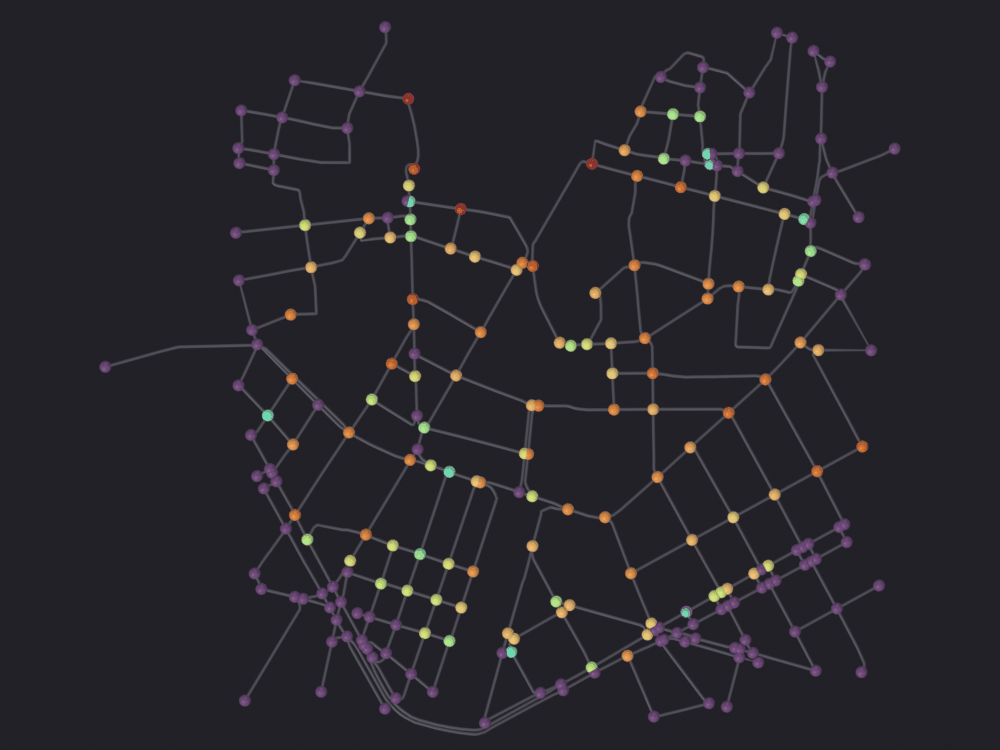

[PASS] 1_snapping_catchment.png legible — 8.9% ink (healthy range 0.5–60%)


In [13]:
EDGE_NEUTRAL = (0.085, 0.080, 0.100)

nb.figure(net, "renders/08_routing/1_snapping_catchment",
          look='ink', color_attribute="node_catchment_m",
          clip_high_pct=98, edge_color=EDGE_NEUTRAL)

## 2 · Three distances between the same two points

"The distance between A and B" is at least three different numbers.
`osmnx_calc_node_pair_distance` computes all three at once: it picks
great-circle or Euclidean according to whether the graph is projected, routes
by `length`, and divides. The quotient is **circuity**, the factor by which
the streets lengthen a journey over the crow's flight.

In [14]:
node_a, node_b = snapped[0], snapped[1]
props.osmnx_dist_node_a = str(node_a)
props.osmnx_dist_node_b = str(node_b)

sg.graphs.activate(net)
with nb.quiet():
    result = bpy.ops.scigraphs.osmnx_calc_node_pair_distance()
print(f"osmnx_calc_node_pair_distance -> {'/'.join(result)}")
print(f"  straight line   {net.get('osmnx_pair_straight_m'):8.1f} m   "
      f"({net.get('osmnx_pair_straight_method')})")
print(f"  by street       {net.get('osmnx_pair_network_m'):8.1f} m")
print(f"  circuity        {net.get('osmnx_pair_circuity'):8.3f}")
print(f"  travel time     "
      f"{'not reported' if 'osmnx_pair_travel_min' not in net.keys() else format(net['osmnx_pair_travel_min'], '.2f') + ' min'}")

check("the operator's circuity is the ratio it says it is",
      abs(net.get("osmnx_pair_circuity")
      - net.get("osmnx_pair_network_m")
      / net.get("osmnx_pair_straight_m")) < 1e-6)
check("the travel-time line is simply absent, not zero",
      "osmnx_pair_travel_min" not in net.keys(),
      "the operator deletes the property when the graph has no travel "
      "times (spatial_operators.py:1288-1291); section 3 adds them, and "
      "nothing on the panel distinguishes 'no travel times' from 'not "
      "computed yet'")

Shortest path: 28 nodes, 1867.7m [length]
Info: Straight: 561.6 m · Network: 1867.7 m · Circuity: 3.326
osmnx_calc_node_pair_distance -> FINISHED
  straight line      561.6 m   (Great-circle (haversine))
  by street         1867.7 m
  circuity           3.326
  travel time     not reported
[PASS] the operator's circuity is the ratio it says it is
[PASS] the travel-time line is simply absent, not zero — the operator deletes the property when the graph has no travel times (spatial_operators.py:1288-1291); section 3 adds them, and nothing on the panel distinguishes 'no travel times' from 'not computed yet'


True

Circuity above 3 is the one-way system, not a defect: the crow's
flight is symmetric and the drive is not, so the same pair measured the other
way round gives a different number. Any statistic averaging over unordered
pairs is blind to that. `ox.basic_stats`' `circuity_avg` is computed on the
*undirected* graph and describes the shape of the streets, not the cost of
using them.

In [15]:
with nb.quiet():
    there = routing.calculate_shortest_path(G, node_a, node_b, weight="length")
    back = routing.calculate_shortest_path(G, node_b, node_a, weight="length")
print(f"A -> B  {there['distance_m']:8.1f} m")
print(f"B -> A  {back['distance_m']:8.1f} m")
print(f"difference {abs(there['distance_m'] - back['distance_m']):8.1f} m")

check("a drive network is not symmetric",
      there["distance_m"] != back["distance_m"],
      "so 'the distance between A and B' needs a direction")

Shortest path: 28 nodes, 1867.7m [length]
Shortest path: 20 nodes, 1662.7m [length]
A -> B    1867.7 m
B -> A    1662.7 m
difference    205.0 m
[PASS] a drive network is not symmetric — so 'the distance between A and B' needs a direction


True

## 3 · Shortest by what

`osmnx_path_weight` takes `length`, `travel_time` and `elevation_impedance`.
The third is notebook 11's subject and needs elevations this graph does not
have.

* `length` minimizes meters. It does not know that a street is narrow, or
  residential, or full of traffic lights.
* `travel_time` minimizes seconds, which are meters divided by an *assumed*
  speed. Where the speed comes from is notebook 07's subject; it varies by
  street class, so the two weights order the network differently.

`travel_time` does not exist until it is put there. `osmnx_add_edge_speeds`
reads the `maxspeed` tag where there is one and imputes a mean per highway
class where there is not; `osmnx_add_travel_times` divides.

In [16]:
with nb.quiet():
    sg.graphs.activate(net)
    speeds_result = bpy.ops.scigraphs.osmnx_add_edge_speeds()
    sg.graphs.activate(net)
    times_result = bpy.ops.scigraphs.osmnx_add_travel_times()

G = graph_cache.get_osmnx_graph(net)
print(f"osmnx_add_edge_speeds  -> {'/'.join(speeds_result)}")
print(f"osmnx_add_travel_times -> {'/'.join(times_result)}")

by_class = {}
for _u, _v, _k, data in G.edges(keys=True, data=True):
    highway = data.get("highway")
    highway = highway if isinstance(highway, str) else str(highway)
    by_class.setdefault(highway, []).append(float(data["speed_kph"]))

print(f"\n  {'highway':<22} {'edges':>6} {'km/h':>7}")
for highway, values in sorted(by_class.items(), key=lambda kv: -len(kv[1])):
    print(f"  {highway:<22} {len(values):>6} {np.mean(values):>7.1f}")

Edge speeds added (fallback: 30 km/h)
Info: Edge speeds added: 375/375 graph edges, 1565 mesh edges updated (fallback: 30 km/h)
Edge travel times added to graph
Info: Travel times added: 375/375 graph edges, 1565 mesh edges updated
osmnx_add_edge_speeds  -> FINISHED
osmnx_add_travel_times -> FINISHED

  highway                 edges    km/h
  residential               215    28.4
  secondary                  53    40.4
  primary                    51    49.3
  living_street              27    20.1
  tertiary                   17    37.5
  primary_link                8    30.0
  ['living_street', 'residential']      3    28.3
  secondary_link              1    30.0


### Before every routing call: are the weights still there?

Two ways for `travel_time` to vanish between the cell that adds it and the
cell that routes on it, neither raising.

1. Applying a layout zeroes every EDGE attribute on the mesh. `rebuild_edges`
   (`SciGraphs/core/mesh/geometry.py:1227-1248`, called from
   `layout_operators.py:322, 397, 483, 589, 639`) rebuilds the mesh edges and
   the attributes on them do not survive. A geospatial graph should never need
   a layout, but if anything triggers one, `edge_travel_time` on the mesh goes
   to zero silently.
2. The NetworkX graph and the mesh are two different stores. Routing reads the
   graph out of the add-on's in-memory cache, the figures read the mesh. A
   layout breaks the second and not the first; every operator in the
   `osmnx_simplify` family breaks the first and not the second (notebook 10,
   section 3).

Both are checked here and again before the batch in section 5.

In [17]:
def weights_present(graph, obj):
    """(edges with travel_time on the graph, non-zero mesh edge values)."""
    on_graph = sum(1 for _u, _v, _k, d in graph.edges(keys=True, data=True)
                   if d.get("travel_time") not in (None, ""))
    layer = obj.data.attributes.get("edge_travel_time")
    if layer is None:
        return on_graph, None
    values = np.zeros(len(obj.data.edges), dtype=np.float32)
    layer.data.foreach_get("value", values)
    return on_graph, int((values > 0).sum())


on_graph, on_mesh = weights_present(G, net)
print(f"travel_time on the graph  {on_graph} of {G.number_of_edges()} edges")
print(f"edge_travel_time on the mesh {on_mesh} of {len(net.data.edges)} "
      "mesh edges non-zero")

check("every edge can be routed on by time",
      on_graph == G.number_of_edges(),
      "calculate_shortest_path refuses rather than routing on a partial "
      "weight (routing.py:110-121), and that guard is the right one")
check("and the mesh still matches the graph after both operators",
      graph_and_mesh_agree(G, net),
      "`osmnx_add_edge_speeds` and `osmnx_add_travel_times` write to both, "
      "which is not true of the operators listed in section 0")

travel_time on the graph  375 of 375 edges
edge_travel_time on the mesh 1492 of 1492 mesh edges non-zero
[PASS] every edge can be routed on by time — calculate_shortest_path refuses rather than routing on a partial weight (routing.py:110-121), and that guard is the right one
[PASS] and the mesh still matches the graph after both operators — `osmnx_add_edge_speeds` and `osmnx_add_travel_times` write to both, which is not true of the operators listed in section 0


True

### And is `length` in meters?

It is, on this graph, because OSMnx computed it during the download with a
great-circle formula. It stops being so the moment anyone runs
`osmnx_add_edge_lengths` on an unprojected graph. `add_edge_lengths`
(`core/osmnx/edge_attributes.py:29-56`) takes `geometry.length`, a shapely
length in whatever units the coordinates are, or falls back to Euclidean
distance over the raw `x`/`y`; on an EPSG:4326 graph both are degrees. Its
docstring says the graph "should be projected for accurate results" and
neither it nor the operator checks.

That is not an inaccuracy but a change of units by a factor of a hundred
thousand, applied to the attribute every route here minimizes. Measured on a
copy, so nothing below is affected.

In [18]:
edge_attributes = importlib.import_module("scigraphs_core.osmnx.edge_attributes")

probe = G.copy()
before = np.array([float(d["length"])
                  for _u, _v, _k, d in probe.edges(keys=True, data=True)])
edge_attributes.add_edge_lengths(probe)
after = np.array([float(d["length"])
                 for _u, _v, _k, d in probe.edges(keys=True, data=True)])

print(f"mean edge length, as downloaded     {before.mean():12.5f}")
print(f"mean edge length, after the operator {after.mean():12.5f}")
print(f"ratio                               {before.mean() / after.mean():12.0f}")
print(f"the second one in meters would be    "
      f"{meters(after.mean()):12.2f}   (if the offset were pure latitude)")

check("add_edge_lengths silently changes the unit",
      after.mean() < before.mean() / 1000,
      "a network of 31.8 km becomes one of 0.33 'kilometers', every route "
      "is still ordered correctly because the scale factor is nearly "
      "uniform, and every reported distance is wrong")

Edge lengths added to graph
mean edge length, as downloaded         84.75395
mean edge length, after the operator      0.00087
ratio                                      97291
the second one in meters would be           96.98   (if the offset were pure latitude)
[PASS] add_edge_lengths silently changes the unit — a network of 31.8 km becomes one of 0.33 'kilometers', every route is still ordered correctly because the scale factor is nearly uniform, and every reported distance is wrong


True

### Only one of the two operators honors the weight

`scigraphs.find_shortest_path` is the generic graph operator. It builds its
graph through `parse_graph_data`, which returns `GraphData(nodes, edges, None)`
(`SciGraphs/core/mesh/mesh_utils.py:100`), and `GraphData` has no
`edge_weights` field (`SciGraphs/core/algorithms/graph.py:3-8`). Every weighted
branch in `SciGraphs/core/algorithms/pathfinding.py` is guarded by
`hasattr(graph_data, 'edge_weights')`, always false, so every edge costs `1.0`
and the hop count is reported as `shortest_path_length`.

`scigraphs.osmnx_shortest_path` is a different code path
(`spatial_operators.py:567-572` into `core/osmnx/routing.py`) and hands the
weight's name to `ox.shortest_path`, which is Dijkstra over that attribute.

A hop count is a legitimate thing to want; the trouble is that two nearly
identical names answer different questions.

In [19]:
node_ids = str(net.get("nodes_data", "")).split(",")
index_of = {int(n): i for i, n in enumerate(node_ids) if n.lstrip("-").isdigit()}

props.osmnx_shortest_path_source = str(node_a)
props.osmnx_shortest_path_target = str(node_b)
props.osmnx_path_weight = 'length'
sg.graphs.activate(net)
with nb.quiet():
    bpy.ops.scigraphs.osmnx_shortest_path()

props.pathfinding_source = str(index_of[node_a])
props.pathfinding_target = str(index_of[node_b])
props.pathfinding_algorithm = 'DIJKSTRA'
sg.graphs.activate(net)
with nb.quiet():
    generic = bpy.ops.scigraphs.find_shortest_path()

print(f"osmnx_shortest_path   {net.get('osmnx_path_distance_m'):8.1f} m over "
      f"{net.get('osmnx_path_num_edges')} edges")
print(f"find_shortest_path    {net.get('shortest_path_length'):8.1f}   over "
      f"{net.get('shortest_path_nodes') - 1} edges  <- hops, not meters")

check("the generic operator's 'distance' is a hop count",
      abs(net.get("shortest_path_length")
      - (net.get("shortest_path_nodes") - 1)) < 1e-6,
      "GraphData carries no edge weights, so every edge costs 1.0")
check("the OSMnx operator does read the weight",
      net.get("osmnx_path_distance_m") > 100.0,
      "meters, from `ox.shortest_path(G, o, d, weight='length')`")

Shortest path: 28 nodes, 1867.7m [length]
Info: Path: 1.87 km, 3.6 min (28 nodes)
Info: Path found: 11 nodes, distance: 10.00
osmnx_shortest_path     1867.7 m over 27 edges
find_shortest_path        10.0   over 10 edges  <- hops, not meters
[PASS] the generic operator's 'distance' is a hop count — GraphData carries no edge weights, so every edge costs 1.0
[PASS] the OSMnx operator does read the weight — meters, from `ox.shortest_path(G, o, d, weight='length')`


True

### Two hundred pairs

How often the weight changes anything is a property of the network: a grid of
identical residential streets leaves the speed nothing to trade against.
Ciutat Vella has a primary road through it at 50 km/h and living streets at
20. Two hundred origin-destination pairs from the strongly connected
component, fixed seed. Notebook 11 asks the same question of the gradient
weight over 80 pairs on the Albaicín and gets 5.

In [20]:
SAMPLE = 200
od_rng = random.Random(20260812)

comparisons = []
with nb.quiet():
    while len(comparisons) < SAMPLE:
        origin, target = od_rng.sample(routable, 2)
        by_distance = routing.calculate_shortest_path(
            G, origin, target, weight="length")
        by_time = routing.calculate_shortest_path(
            G, origin, target, weight="travel_time")
        if not by_distance or "path" not in by_distance:
            continue
        if not by_time or "path" not in by_time:
            continue
        comparisons.append((origin, target,
                           by_distance["path"], by_time["path"]))


def weight_of(path, attribute):
    return float(nx.path_weight(G, path, weight=attribute))


changed = [c for c in comparisons if c[2] != c[3]]
print(f"{len(comparisons)} origin-destination pairs, "
      f"{len(changed)} took a different route under travel time "
      f"({100 * len(changed) / len(comparisons):.0f} %)")

extra_m = np.array([weight_of(t, "length") - weight_of(d, "length")
                   for _o, _d2, d, t in changed])
saved_s = np.array([weight_of(d, "travel_time") - weight_of(t, "travel_time")
                   for _o, _d2, d, t in changed])
base_m = np.array([weight_of(d, "length") for _o, _d2, d, _t in changed])
base_s = np.array([weight_of(d, "travel_time") for _o, _d2, d, _t in changed])
overlap = np.array([len(edge_set(d) & edge_set(t)) / len(edge_set(d) | edge_set(t))
                   for _o, _d2, d, t in changed])

print("\nwhere it changed, the time-optimal route is:")
print(f"  longer by  {np.median(extra_m):+6.0f} m median, "
      f"{np.max(extra_m):+6.0f} m worst  "
      f"({100 * np.median(extra_m / base_m):+.1f} % / "
      f"{100 * np.max(extra_m / base_m):+.1f} % of the distance)")
print(f"  faster by  {np.median(saved_s):+6.1f} s median, "
      f"{np.max(saved_s):+6.1f} s worst  "
      f"({100 * np.median(saved_s / base_s):+.1f} % / "
      f"{100 * np.max(saved_s / base_s):+.1f} % of the time)")
print(f"  edge overlap with the distance route: "
      f"{np.median(overlap):.2f} median, {overlap.min():.2f} least")

check("the weight changes some routes and not most of them",
      0 < len(changed) < len(comparisons) / 2,
      "on flat ground the two weights differ only where a faster class of "
      "street runs roughly parallel to a shorter one")
check("where they differ, they differ substantially",
      np.median(overlap) < 0.75,
      f"the two routes share {100 * np.median(overlap):.0f} % of their "
      "edges at the median: different ways round, not a block swapped")

Shortest path: 10 nodes, 953.3m [length]
Shortest path: 10 nodes, 953.3m [travel_time]
Shortest path: 11 nodes, 932.7m [length]
Shortest path: 11 nodes, 932.7m [travel_time]
Shortest path: 26 nodes, 1442.3m [length]
Shortest path: 26 nodes, 1442.3m [travel_time]
Shortest path: 22 nodes, 1688.5m [length]
Shortest path: 22 nodes, 1688.5m [travel_time]
Shortest path: 16 nodes, 1039.4m [length]
Shortest path: 14 nodes, 1104.8m [travel_time]
Shortest path: 12 nodes, 1036.8m [length]
Shortest path: 12 nodes, 1036.8m [travel_time]
Shortest path: 40 nodes, 3147.2m [length]
Shortest path: 40 nodes, 3147.2m [travel_time]
Shortest path: 11 nodes, 919.8m [length]
Shortest path: 11 nodes, 919.8m [travel_time]
Shortest path: 17 nodes, 1538.5m [length]
Shortest path: 17 nodes, 1538.5m [travel_time]
Shortest path: 21 nodes, 1443.9m [length]
Shortest path: 21 nodes, 1443.9m [travel_time]
Shortest path: 16 nodes, 1316.8m [length]
Shortest path: 16 nodes, 1316.8m [travel_time]
Shortest path: 17 nodes, 13

True

The trade is small in both directions, which is what a dense
medieval center with a 30 km/h default looks like. With a motorway through it
the shape is the opposite: a large detour for a large saving in time.

## 4 · Drawing a route, which is harder than it looks

Highlighting a subset of a graph is a different problem from coloring a
continuous attribute. Two things get in the way, both of which have already
produced a bad figure in this suite.

There is no per-edge color on a graph. Blender color attributes live only on
the `POINT` and `CORNER` domains; `CORNER` needs faces and a graph mesh has
none, so `color_domain_for` (`SciGraphs/core/coloring/attributes.py:144-158`)
falls through to `POINT` and `values_for_color_domain` (`:225-246`) averages
each edge value over the vertices it touches. The tube between two nodes is
then a gradient between two averages. For a continuous quantity that is
defensible; for a 0/1 membership flag it is not, because a junction where one
route edge meets three others reads 0.25 and the route dissolves into a smear.

`osmnx_shortest_path` writes exactly such a flag: `on_path_edge`, an `INT`
`EDGE` attribute (`core/osmnx/mesh_bridge.py:263-275`).

In [21]:
flag = net.data.attributes.get("on_path_edge")
raw = np.zeros(len(net.data.edges), dtype=np.int32)
flag.data.foreach_get("value", raw)

promoted = color_attrs.values_for_color_domain(
    net.data, 'EDGE', raw.astype(float), 'POINT')

print(f"on_path_edge domain     {flag.domain}, values {sorted(set(raw.tolist()))}")
print(f"color domain chosen    "
      f"{color_attrs.color_domain_for('EDGE', net.data)}  "
      f"(the mesh has {len(net.data.loops)} loops, so CORNER is unavailable)")
print(f"distinct values reaching the shader: "
      f"{len(set(np.round(promoted, 4).tolist()))}")
print(f"    {sorted(set(np.round(promoted, 3).tolist()))[:8]} …")
print(f"vertices holding exactly 1.0: {int((promoted == 1.0).sum())} of "
      f"{int((raw == 1).sum())} route mesh edges")

check("a binary edge flag does not survive the trip to the shader",
      len(set(np.round(promoted, 4).tolist())) > 2,
      "two values go in and a ramp of averages comes out")

on_path_edge domain     EDGE, values [0, 1]
color domain chosen    POINT  (the mesh has 0 loops, so CORNER is unavailable)
distinct values reaching the shader: 4
    [0.0, 0.5, 0.667, 1.0] …
vertices holding exactly 1.0: 107 of 132 route mesh edges
[PASS] a binary edge flag does not survive the trip to the shader — two values go in and a ramp of averages comes out


True

Second, turbo has two ends and both are dark. Even if the flag
survived, a two-valued attribute uses the colormap's two extreme stops, and
turbo's are its darkest: sampled off the ramp, luminance 28 and 29 out of 255,
against 182 and 190 a third and two thirds of the way along. The route is a
dark red thread on a dark blue web, and what makes it visible is hue.

On empty ground that is enough and the figure below is readable. It stops
being enough the moment anything else is in the frame: in notebook 13 the same
kind of attribute over extruded buildings rendered *below* the roofs, and the
whole city had to be dimmed to get the data back on top.

The figure is made here deliberately, so the fix has something to compare
against, and rendered twice, once with the route and once with the attribute
zeroed everywhere. `shrink=False` on both: `sg.preview.shrink_png` re-quantizes to a
256-entry palette chosen per image, so two nearly identical frames would
otherwise differ by their palettes as much as by their content.

  Promoted 4 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> on_path_edge  ·  on_path_edge -> turbo [log]  [0 … 1] on Point
  Promoted 4 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> on_path_edge_off  ·  on_path_edge_off -> turbo [log]  [0 … 1e-09] on Point


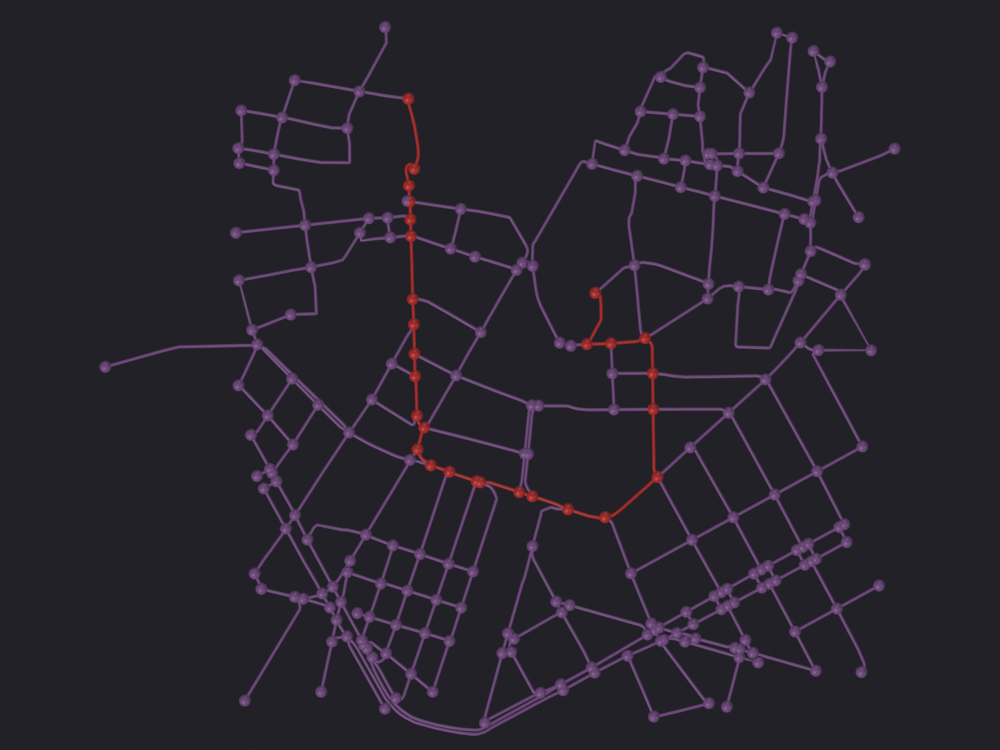

[PASS] 2_route_naive.png legible — 9.3% ink (healthy range 0.5–60%)


True

In [22]:
blank = np.zeros(len(net.data.edges), dtype=np.int32)
off = net.data.attributes.new(name="on_path_edge_off", type='INT',
                              domain='EDGE')
off.data.foreach_set("value", blank.tolist())

naive_path = nb.render(
    net, "renders/08_routing/2_route_naive", look='ink',
    color_attribute="on_path_edge", edge_color=EDGE_NEUTRAL,
    shrink=False, verbose=False)
naive_off = nb.render(
    net, "renders/08_routing/2_route_naive_off", look='ink',
    color_attribute="on_path_edge_off", edge_color=EDGE_NEUTRAL,
    shrink=False, verbose=False)
nb.show(naive_path)
nb.check_render(naive_path)

### The fix: geometry carries membership, color carries magnitude

The route becomes a second object: a copy of the network mesh holding every
vertex but only the route's edges, drawn with tubes about two and a half times
the radius of the ones underneath. Coaxial cylinders of different radii
enclose one another rather than z-fighting, so no depth offset is needed. Its
node spheres shrink to nothing and the fabric underneath goes flat and dim.

That leaves the colormap a continuous quantity: meters from the origin, a
`POINT` attribute, so it is not averaged, interpolating it along a tube is
exactly what it means, and it spends the whole ramp, where turbo's light is.

Thickness is the reading rule: the fat ribbon is the distance-optimal route,
the thin one the time-optimal route. Where they agree the fat one encloses the
thin one; where they disagree there are two. Both run violet at the origin to
red at the destination, so the colors read against each other say where along
the trip the detour is paid for.

In [23]:
featured = max(changed,
               key=lambda c: (len(edge_set(c[2]) & edge_set(c[3])) > 0,
               weight_of(c[2], "travel_time")
               - weight_of(c[3], "travel_time")))
origin, target, path_distance, path_time = featured

print(f"origin {origin}  ->  target {target}")
print(f"  {'weight':<14} {'length':>9} {'time':>8} {'edges':>6}")
for label, path in (("length", path_distance), ("travel_time", path_time)):
    print(f"  {label:<14} {weight_of(path, 'length'):>7.0f} m "
          f"{weight_of(path, 'travel_time'):>6.1f} s "
          f"{len(path) - 1:>6}")
shared = edge_set(path_distance) & edge_set(path_time)
print(f"  shared edges  {len(shared)}, "
      f"distance-only {len(edge_set(path_distance) - shared)}, "
      f"time-only {len(edge_set(path_time) - shared)}")

check("the featured pair has both a shared spine and a divergence",
      len(shared) > 0 and len(edge_set(path_distance) - shared) > 0)

origin 475183429  ->  target 29834287
  weight            length     time  edges
  length            1511 m  169.4 s     16
  travel_time       1577 m  126.4 s     22
  shared edges  1, distance-only 15, time-only 21
[PASS] the featured pair has both a shared spine and a divergence


True

In [24]:
def mesh_edges_of(obj, path):
    """The mesh edge indices a graph route runs over."""
    mapping = mesh_bridge.build_edge_mapping(obj)
    indices = set()
    for u, v in zip(path[:-1], path[1:]):
        indices.update(mapping.get((str(u), str(v)), []))
    return indices


def cumulative_meters(graph, path):
    """`{node id: meters from the origin}` along a route."""
    total = 0.0
    out = {path[0]: 0.0}
    for u, v in zip(path[:-1], path[1:]):
        data = min(graph.get_edge_data(u, v).values(),
                   key=lambda d: d.get("length", float("inf")))
        total += float(data.get("length", 0.0) or 0.0)
        out[v] = total
    return out


def route_object(source, path, name, collection="C2G_Routing"):
    """A new object holding every vertex of `source` but only `path`'s edges.

    Built from coordinates rather than copied. `source.data.copy()` is wrong
    twice over: it brings the material slots with it, so the route inherits the
    fabric's flat color and the colormap lands in a slot nothing reads, and
    deleting the unwanted edges afterwards with
    `bmesh.ops.delete(context='EDGES')` also removes every vertex those edges
    were the last user of, which is all but a few dozen of them.

    Every vertex is kept because `sg.render.measure` derives the glyph radius
    and the camera fit from the node cloud, and an object holding three percent
    of the network would be sized as though it were a different graph.
    """
    keep = mesh_edges_of(source, path)

    coords = np.empty(len(source.data.vertices) * 3, dtype=np.float32)
    source.data.vertices.foreach_get("co", coords)
    pairs = np.empty(len(source.data.edges) * 2, dtype=np.int32)
    source.data.edges.foreach_get("vertices", pairs)
    pairs = pairs.reshape(-1, 2)

    mesh = bpy.data.meshes.new(name)
    mesh.from_pydata(coords.reshape(-1, 3).tolist(),
                     [tuple(int(v) for v in pairs[i]) for i in sorted(keep)],
                     [])
    mesh.update()

    obj = bpy.data.objects.new(name, mesh)
    sg.graphs.collection(collection).objects.link(obj)
    obj.matrix_world = source.matrix_world.copy()
    for key in ("nodes_data", "edges_data", "num_nodes",
                "is_osmnx", "osmnx_scale"):
        if key in source.keys():
            obj[key] = source[key]
    obj["num_edges"] = len(mesh.edges)

    # `node_cloud` reads `is_intersection` when `node_positions` is missing,
    # which on an OSMnx import it always is.
    flags = np.empty(len(source.data.vertices), dtype=np.int32)
    source.data.attributes["is_intersection"].data.foreach_get("value", flags)
    layer = mesh.attributes.new(name="is_intersection", type='INT',
                                domain='POINT')
    layer.data.foreach_set("value", flags.tolist())

    node_attribute(obj, cumulative_meters(G, path), "route_progress_m")
    return obj


route_d = route_object(net, path_distance, "Route_by_distance")
route_t = route_object(net, path_time, "Route_by_time")

for obj, path in ((route_d, path_distance), (route_t, path_time)):
    print(f"{obj.name:<20} {len(obj.data.vertices)} vertices, "
          f"{len(obj.data.edges)} mesh edges, "
          f"progress 0 … {weight_of(path, 'length'):.0f} m")

check("the route objects keep every vertex",
      len(route_d.data.vertices) == len(net.data.vertices),
      "so the autoscaler measures the same graph they are drawn over")

Route_by_distance    1374 vertices, 65 mesh edges, progress 0 … 1511 m
Route_by_time        1374 vertices, 77 mesh edges, progress 0 … 1577 m
[PASS] the route objects keep every vertex — so the autoscaler measures the same graph they are drawn over


True

The two highlights are sized and colored by hand.
`render_eevee` builds the Geometry Nodes tree, the material and the coloring
only for the object it is *framing*, so anything composed alongside it has to
be prepared first and in that order: the tree bakes the glyph sizes in at
build time, and the coloring has to survive the rebuild rather than precede
it.

In [25]:
# The fabric's node spheres set the scale, not its tubes. At the default 0.35
# they are 12.3 m across against a 3.1 m tube, so a highlight twice the tube's
# radius is swallowed at every junction and the ribbon renders dashed.
FABRIC_NODE_FRACTION = 0.08
FABRIC_EDGE_RATIO = 0.9

base = sg.render.autoscale_geometry(net, node_fraction=FABRIC_NODE_FRACTION,
                                    edge_ratio=FABRIC_EDGE_RATIO,
                                    verbose=False)
print(f"fabric node radius {base['node_radius'] / 0.001:5.1f} m")
print(f"fabric tube radius {base['edge_radius'] / 0.001:5.1f} m")

for obj, ratio in ((route_d, 4.0), (route_t, 1.5)):
    sg.render.autoscale_geometry(obj, verbose=False)
    obj["scigraphs_node_size"] = base["node_radius"] * 0.02
    obj["scigraphs_edge_thickness"] = base["edge_radius"] * ratio
    sg.render.material(obj)
    sg.render.geometry_nodes(obj)
    sg.render.color_graph(obj, "route_progress_m", colormap="turbo",
                          nodes_only=False, verbose=False)
    print(f"{obj.name:<20} tube radius "
          f"{obj['scigraphs_edge_thickness'] / 0.001:5.1f} m "
          f"({ratio:.1f} x the fabric's, "
          f"{obj['scigraphs_edge_thickness'] / base['node_radius']:.1f} x its "
          "beads)")

fabric node radius   2.8 m
fabric tube radius   2.5 m
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> route_progress_m  ·  route_progress_m -> turbo [log]  [0 … 1511] on Point
Route_by_distance    tube radius  10.1 m (4.0 x the fabric's, 3.6 x its beads)
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> route_progress_m  ·  route_progress_m -> turbo [log]  [0 … 1577] on Point
Route_by_time        tube radius   3.8 m (1.5 x the fabric's, 1.4 x its beads)


A graph keeps its last coloring, and asking for a plain color
does not take it off. `bpy.ops.scigraphs.color_apply` leaves a material called
`<object>_SciGraphsColor` in slot 0 reproducing the colormap in shader nodes,
and `sg.render.material()` never overwrites a material it did not build
(`sg.render.py:736-740`), so `color=` has no effect while that one is there.
When it does build a material it wires the mesh's existing color layer into
it (`:759-765`), so removing the material alone would put the same ramp back.

Both come off explicitly. Left in place, `color=` is ignored silently and the
fabric goes on rendering in the previous figure's ramp at turbo's bottom stop,
one of the two darkest on the scale, and so disappears.

In [26]:
for layer in list(net.data.color_attributes):
    net.data.color_attributes.remove(layer)
for key in ("scigraphs_last_color_attribute", "scigraphs_color_attr"):
    if key in net.keys():
        del net[key]
net.data.materials.clear()
print(f"color layers left on the fabric: {len(net.data.color_attributes)}, "
      f"materials: {len(net.data.materials)}")

color layers left on the fabric: 0, materials: 0


Twice from the same camera, as with the naive figure: once with
the highlights and once with them hidden. The pixels that changed are the ones
the route reaches, and their median luminance against the median of the
fabric's own ink says whether the data ended up above the furniture.

  Promoted 4 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
  Promoted 4 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


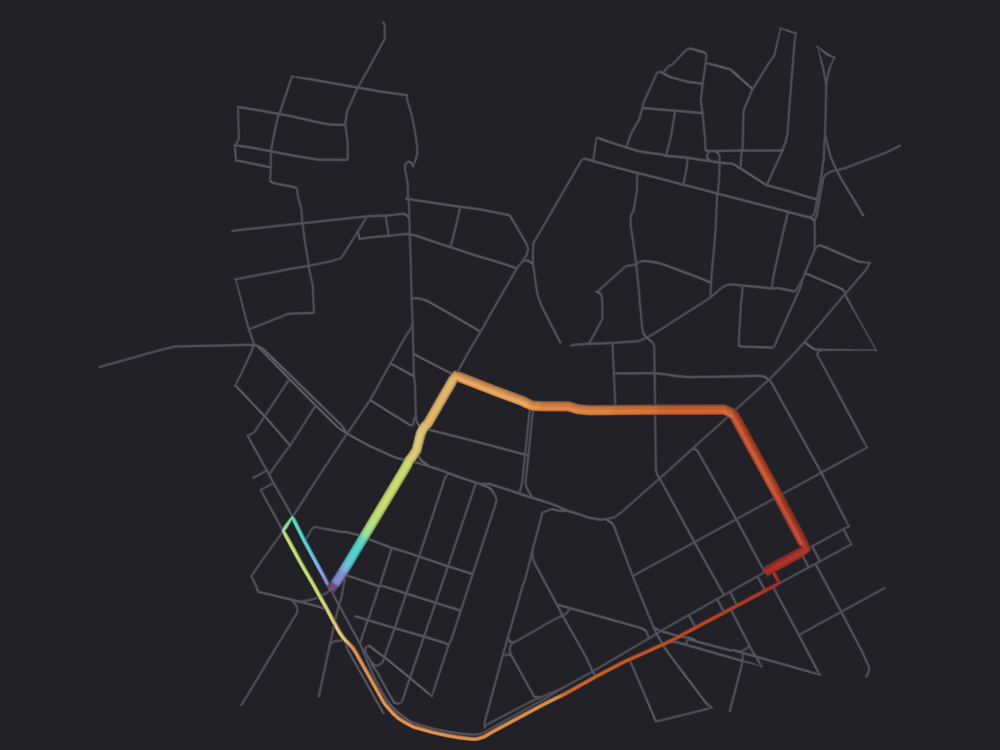

[PASS] 3_route_two_weights.png legible — 7.1% ink (healthy range 0.5–60%)


True

In [27]:
composite = nb.render(
    net, "renders/08_routing/3_route_two_weights", look='ink',
    isolate=False, color=EDGE_NEUTRAL, node_fraction=FABRIC_NODE_FRACTION,
    edge_ratio=FABRIC_EDGE_RATIO, shrink=False, verbose=False)
fabric_only = nb.render(
    net, "renders/08_routing/3_route_fabric_only", look='ink',
    isolate=False, color=EDGE_NEUTRAL, node_fraction=FABRIC_NODE_FRACTION,
    edge_ratio=FABRIC_EDGE_RATIO, hide=[route_d, route_t],
    shrink=False, verbose=False)
nb.show(composite)
nb.check_render(composite)

In [28]:
def luminance_map(path):
    from PIL import Image
    rgb = np.asarray(Image.open(str(path)).convert("RGB"), dtype=np.float32)
    return 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]


def highlight_contrast(with_highlight, without):
    """(reach, median luminance of the highlight, of the fabric's ink, delta)."""
    a, b = luminance_map(with_highlight), luminance_map(without)
    changed_px = np.abs(a - b) > 12
    background = b[0, 0]
    fabric_px = (np.abs(b - background) > 12) & ~changed_px
    high = float(np.median(a[changed_px])) if changed_px.any() else float("nan")
    low = float(np.median(b[fabric_px])) if fabric_px.any() else float("nan")
    return float(changed_px.mean()), high, low, high - low


naive_reach, naive_high, naive_low, naive_delta = highlight_contrast(
    naive_path, naive_off)
reach, high, low, delta = highlight_contrast(composite, fabric_only)

print(f"  {'':<26} {'naive':>8} {'fixed':>8}")
print(f"  {'share of frame reached %':<26} {100 * naive_reach:>8.2f} "
      f"{100 * reach:>8.2f}")
print(f"  {'median luminance, route':<26} {naive_high:>8.1f} {high:>8.1f}")
print(f"  {'median luminance, fabric':<26} {naive_low:>8.1f} {low:>8.1f}")
print(f"  {'route minus fabric':<26} {naive_delta:>+8.1f} {delta:>+8.1f}")

check("the highlight is brighter than what it is drawn over",
      delta > 40,
      "geometry carries membership, color carries magnitude, and the "
      "fabric is flattened out of the way")

                                naive    fixed
  share of frame reached %       0.29     1.49
  median luminance, route        68.3    121.3
  median luminance, fabric       77.0     71.1
  route minus fabric             -8.7    +50.2
[PASS] the highlight is brighter than what it is drawn over — geometry carries membership, color carries magnitude, and the fabric is flattened out of the way


True

The ink fraction cannot see any of this. `check_render` counts
pixels that differ from the frame's corner, so moving a color without moving
a pixel leaves the count untouched: it catches an empty render and a saturated
one, nothing between. The pair of frames above is the check that does see it.

In [29]:
print(f"ink, naive figure with the route      {100 * nb.ink(naive_path):5.2f} %")
print(f"ink, the same figure with no route    {100 * nb.ink(naive_off):5.2f} %")
print(f"contrast, naive / fixed               {naive_delta:+6.1f} / "
      f"{delta:+6.1f} levels")

ink, naive figure with the route       9.30 %
ink, the same figure with no route     9.31 %
contrast, naive / fixed                 -8.7 /  +50.2 levels


## 5 · k shortest paths

`k_shortest_paths` (`core/osmnx/routing.py:166-221`) tries
`ox.routing.k_shortest_paths` and falls back to
`networkx.shortest_simple_paths`; both are Yen's algorithm, which enumerates
simple paths in increasing order of weight. So `osmnx_k_shortest` returns the
k cheapest routes that do not revisit a node, with no constraint that they
differ from one another in any interesting way. A shortest path with one block
swapped is a legitimate second-shortest path, and Yen produces it before the
genuinely different way round.

The pair asked below is the one section 3 featured, where the two weights
disagree as much as anywhere here.

In [30]:
K = 8
sg.graphs.activate(net)
props.osmnx_shortest_path_source = str(origin)
props.osmnx_shortest_path_target = str(target)
props.osmnx_k_shortest = K
props.osmnx_path_weight = 'length'
with nb.quiet():
    k_result = bpy.ops.scigraphs.osmnx_k_shortest()

print(f"osmnx_k_shortest -> {'/'.join(k_result)}")
print(f"  osmnx_k_shortest_count {net.get('osmnx_k_shortest_count')}")
print(f"  osmnx_k_shortest_km    "
      f"{[round(v, 3) for v in net.get('osmnx_k_shortest_km')]}")

with nb.quiet():
    alternatives = routing.k_shortest_paths(G, origin, target, k=K,
                                            weight="length")

best = edge_set(alternatives[0]["path"])
print(f"\n  {'#':>2} {'length':>9} {'vs best':>8} {'time':>8} "
      f"{'overlap':>8} {'new edges':>10}")
for index, entry in enumerate(alternatives):
    here = edge_set(entry["path"])
    print(f"  {index:>2} {entry['distance_m']:>7.0f} m "
          f"{100 * (entry['distance_m'] / alternatives[0]['distance_m'] - 1):>+7.1f}% "
          f"{entry.get('travel_time_seconds', float('nan')):>6.0f} s "
          f"{len(here & best) / len(here | best):>8.2f} "
          f"{len(here - best):>10}")

pairwise = [len(edge_set(a["path"]) & edge_set(b["path"]))
            / len(edge_set(a["path"]) | edge_set(b["path"]))
            for i, a in enumerate(alternatives)
            for b in alternatives[i + 1:]]
spread = (alternatives[-1]["distance_m"] / alternatives[0]["distance_m"]) - 1
matches_time_route = [i for i, entry in enumerate(alternatives)
                      if entry["path"] == path_time]

print(f"\nmean pairwise edge overlap across the {len(alternatives)} routes: "
      f"{np.mean(pairwise):.2f}")
print(f"the {K}th is only {100 * spread:.1f} % longer than the best")
print(f"the travel-time route of section 3 appears in this list at position "
      f"{matches_time_route[0] if matches_time_route else 'not at all'}")

check("all k alternatives are within a few percent of the best",
      spread < 0.12,
      "which is what makes them alternatives at all, and what makes most "
      "of them uninteresting")
check("the time-optimal route is one of the k",
      bool(matches_time_route),
      "routing by time is not reaching for a different kind of object: it "
      "picks the path routing by distance offers at position "
      f"{matches_time_route[0] + 1 if matches_time_route else '?'} of "
      f"{K}")

k-shortest paths: found 8 / k=8
Info: Found 8 routes: 1.51km, 1.53km, 1.58km, 1.58km, 1.60km, 1.64km, 1.64km, 1.66km
osmnx_k_shortest -> FINISHED
  osmnx_k_shortest_count 8
  osmnx_k_shortest_km    [1.511, 1.531, 1.577, 1.578, 1.597, 1.636, 1.642, 1.655]
k-shortest paths: found 8 / k=8

   #    length  vs best     time  overlap  new edges
   0    1511 m    +0.0%    169 s     1.00          0
   1    1531 m    +1.3%    172 s     0.68          3
   2    1577 m    +4.4%    126 s     0.03         21
   3    1578 m    +4.4%    174 s     0.41         11
   4    1597 m    +5.7%    177 s     0.27         14
   5    1636 m    +8.2%    183 s     0.78          2
   6    1642 m    +8.6%    186 s     0.75          4
   7    1655 m    +9.5%    185 s     0.52          5

mean pairwise edge overlap across the 8 routes: 0.38
the 8th is only 9.5 % longer than the best
the travel-time route of section 3 appears in this list at position 2
[PASS] all k alternatives are within a few percent of the best — whi

True

### The same question over many pairs

Forty pairs, k=3 each: how much longer is the second-best route, and how much
of it is new?

In [31]:
second_extra = []
second_overlap = []
with nb.quiet():
    for origin_i, target_i, _d, _t in comparisons[:40]:
        found = routing.k_shortest_paths(G, origin_i, target_i, k=3,
                                         weight="length")
        if not found or len(found) < 2:
            continue
        first, second = edge_set(found[0]["path"]), edge_set(found[1]["path"])
        second_extra.append(found[1]["distance_m"] / found[0]["distance_m"] - 1)
        second_overlap.append(len(first & second) / len(first | second))

second_extra = np.array(second_extra)
second_overlap = np.array(second_overlap)
print(f"{len(second_extra)} pairs with a second path")
print(f"  it is {100 * np.median(second_extra):+.1f} % longer (median), "
      f"{100 * second_extra.max():+.1f} % at worst")
print(f"  within 10 % of the best on {int((second_extra <= 0.10).sum())} of "
      f"{len(second_extra)} pairs")
print(f"  edge overlap with the best route: "
      f"{np.median(second_overlap):.2f} median")

check("a second route is usually nearly free and nearly the same",
      np.median(second_extra) < 0.10 and np.median(second_overlap) > 0.5)

k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shortest paths: found 3 / k=3
k-shorte

True

The overlap number used above is the **Jaccard index over edge
sets**: shared edges divided by total distinct edges, symmetric, bounded and
indifferent to length.

Getting alternatives that are actually alternative means asking for a
*dissimilar* set rather than the k cheapest: penalize edges already used and
re-route, or enforce a maximum overlap. Neither OSMnx nor SciGraphs does that.

> The operator stores the k lengths in `osmnx_k_shortest_km` and marks only
> the first onto the mesh (`routing_operators.py:94-97`). The alternatives
> exist as numbers in a custom property and cannot be drawn through the
> operator at all, so the figure below counts them onto the nodes by hand.

### The figure: how many of the k routes use each junction

A count from 0 to k is a genuine `POINT` quantity, with no averaging and no
membership flag, and it says where the alternatives are forced through the
same gap. Dark violet is zero, so what is colored is the union of the k
routes and the rest of the network stays as ground.

46 nodes lie on at least one of the 8 routes
  on all 8: 3 nodes (the shared spine every alternative is forced through)
  on exactly one: 16 nodes
  Promoted 4 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_k_routes  ·  node_k_routes -> turbo [log]  [0 … 8] on Point


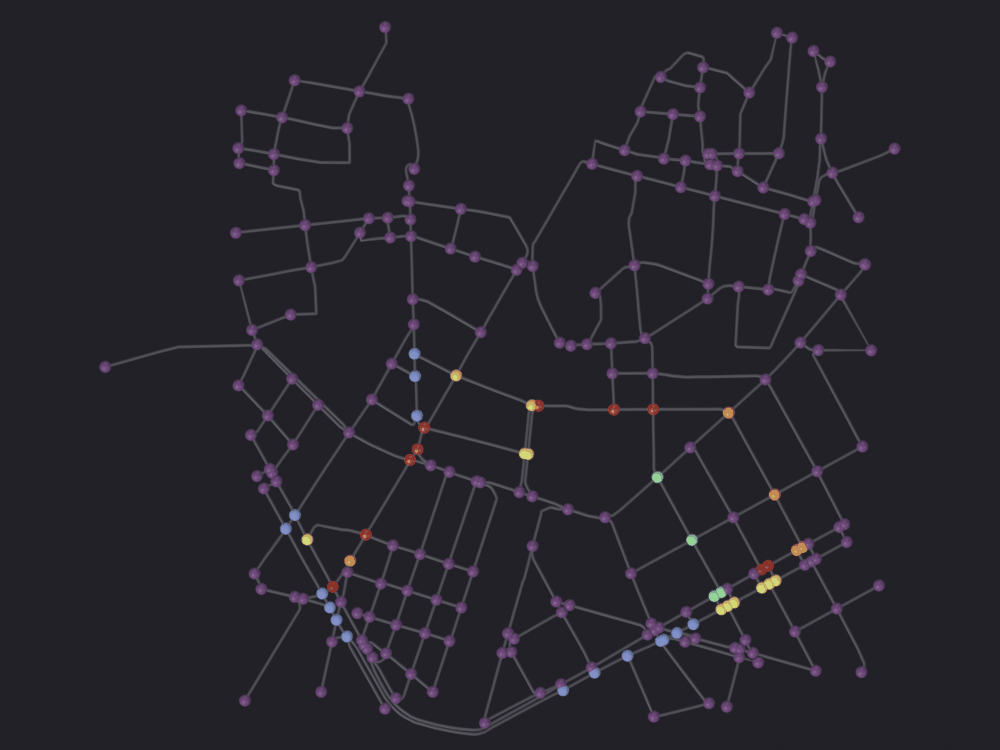

[PASS] 4_k_routes.png legible — 8.9% ink (healthy range 0.5–60%)


In [32]:
through_node = {}
for entry in alternatives:
    for node in set(entry["path"]):
        through_node[node] = through_node.get(node, 0) + 1

written, values = node_attribute(net, through_node, "node_k_routes")
used = np.array([v for v in through_node.values()])
print(f"{len(through_node)} nodes lie on at least one of the {K} routes")
print(f"  on all {K}: {int((used == K).sum())} nodes "
      f"(the shared spine every alternative is forced through)")
print(f"  on exactly one: {int((used == 1).sum())} nodes")

nb.figure(net, "renders/08_routing/4_k_routes",
          look='ink', color_attribute="node_k_routes",
          edge_color=EDGE_NEUTRAL)

## 6 · A thousand routes

`osmnx_batch_routes` is the same Dijkstra run many times over a list of
origins and a list of destinations, optionally across processes. Aggregate a
thousand routes onto the network and you have a map of which streets a uniform
demand would put its traffic on.

> The operator samples without a seed. `sample_random_od_pairs` takes one
> (`core/osmnx/routing.py:386-396`) and `SCIGRAPHS_OT_OSMnxBatchRoutes` does
> not pass it (`routing_operators.py:133`), so two identical invocations give
> two different answers and nothing records which sample produced the numbers
> written onto the object. Demonstrated below, then done properly through the
> core function.

In [33]:
props.osmnx_od_random_n = 50
props.osmnx_od_batch_cpus = 1
twice = []
for _ in range(2):
    sg.graphs.activate(net)
    with nb.quiet():
        bpy.ops.scigraphs.osmnx_batch_routes()
    twice.append((net.get("osmnx_batch_reached"),
                 round(float(net.get("osmnx_batch_mean_dist_m")), 1)))

print("osmnx_batch_routes, run twice with identical settings:")
for reached, mean_m in twice:
    print(f"    {reached}/50 reached, mean {mean_m:.0f} m")

check("the batch operator is not reproducible", twice[0] != twice[1],
      "sample_random_od_pairs accepts a seed and the operator does not "
      "pass one")

Info: Batch: 41/50 reached, mean=1118m
Info: Batch: 40/50 reached, mean=1234m
osmnx_batch_routes, run twice with identical settings:
    41/50 reached, mean 1118 m
    40/50 reached, mean 1234 m
[PASS] the batch operator is not reproducible — sample_random_od_pairs accepts a seed and the operator does not pass one


True

### Done with a seed, and with the unreachable pairs counted

`sample_random_od_pairs` draws origins and destinations independently from all
nodes, with two consequences the summary does not mention: a pair can have the
same node at both ends, and a pair can straddle the boundary of the strongly
connected component and have no route. Both come back as `None` and are
excluded, so `mean_distance_m` is the mean over whatever succeeded.

In [34]:
ROUTES = 1000
pairs = routing.sample_random_od_pairs(G, n=ROUTES, seed=20260812)
origins = [o for o, _d in pairs]
targets = [d for _o, d in pairs]

on_graph, on_mesh = weights_present(G, net)
print(f"weights still present before the batch: {on_graph} edges on the graph, "
      f"{on_mesh} non-zero on the mesh")

with nb.quiet():
    batch = routing.batch_shortest_paths(G, origins, targets, weight="length")

summary = batch["summary"]
same_node = sum(1 for o, d in pairs if o == d)
outside = sum(1 for o, d in pairs if o not in strong or d not in strong)
print(f"\nrequested        {summary['total_pairs']}")
print(f"reached          {summary['reached']} "
      f"({100 * summary['reached'] / summary['total_pairs']:.0f} %)")
print(f"  same node both ends           {same_node}")
print(f"  an end outside the strong component {outside}")
print(f"mean distance    {summary['mean_distance_m']:.0f} m   "
      f"(over the ones that reached)")
print(f"mean travel time {summary['mean_travel_time_s']:.1f} s")

check("one in six uniformly sampled pairs has no route",
      summary["reached"] < summary["total_pairs"],
      "the one-way system, not a bug, but a mean over the survivors is "
      "not a mean over the sample")

weights still present before the batch: 375 edges on the graph, 1492 non-zero on the mesh

requested        1000
reached          843 (84 %)
  same node both ends           2
  an end outside the strong component 318
mean distance    1252 m   (over the ones that reached)
mean travel time 140.7 s
[PASS] one in six uniformly sampled pairs has no route — the one-way system, not a bug, but a mean over the survivors is not a mean over the sample


True

### Counting the routes onto the network

The count goes on the nodes, for the reason section 4 established. It is
heavily skewed, the busiest node carrying some hundreds of times the median,
so the top percentile is clipped.

241 of 243 nodes carry at least one route
  median 40, 90th 154, 99th 258, busiest 267
  the busiest node carries 7 times the median
  Promoted 4 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_route_load  ·  node_route_load -> turbo [log]  [0 … 236.2] on Point


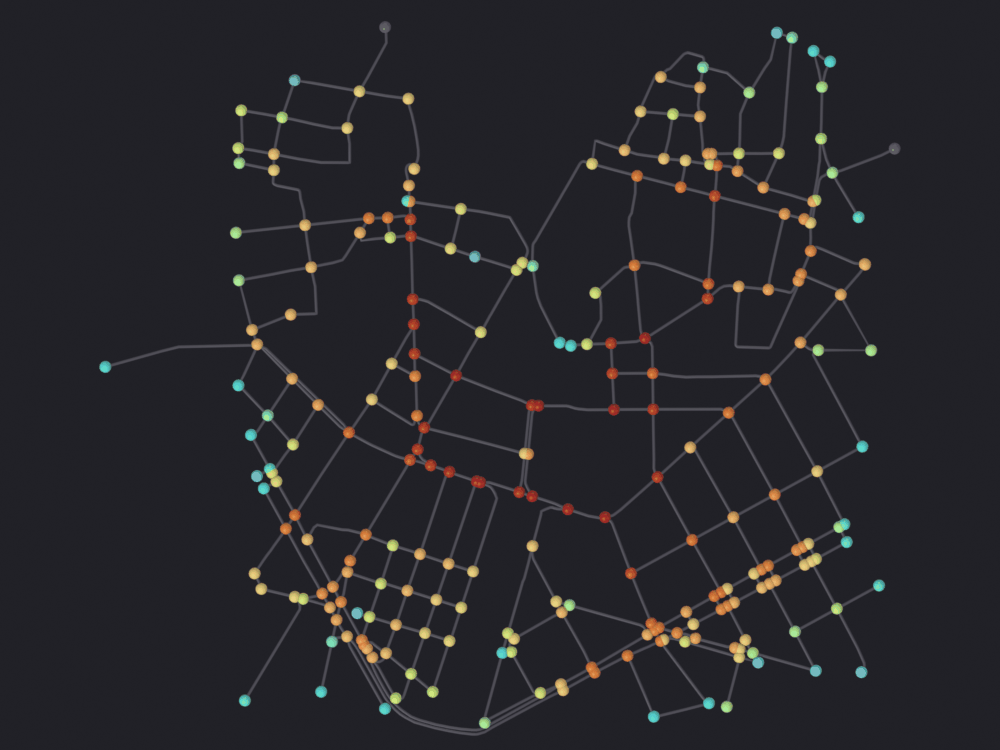

[PASS] 5_route_load.png legible — 9.0% ink (healthy range 0.5–60%)


In [35]:
through = {}
for entry in batch["paths"]:
    if not entry:
        continue
    for node in set(entry["path"]):
        through[node] = through.get(node, 0) + 1

written, load = node_attribute(net, through, "node_route_load")
counts = np.array(sorted(through.values()))
print(f"{len(through)} of {G.number_of_nodes()} nodes carry at least one route")
print(f"  median {np.median(counts):.0f}, 90th {np.percentile(counts, 90):.0f}, "
      f"99th {np.percentile(counts, 99):.0f}, busiest {counts.max():.0f}")
print(f"  the busiest node carries "
      f"{counts.max() / np.median(counts):.0f} times the median")

nb.figure(net, "renders/08_routing/5_route_load",
          look='ink', color_attribute="node_route_load",
          clip_high_pct=98, edge_color=EDGE_NEUTRAL)

### This is a crude betweenness, and crude is doing work

Counting shortest paths through a node is the definition of betweenness
centrality. What is built above differs in four ways, two approximations and
two choices.

* It is a sample, not a census. Betweenness sums over all *n(n-1)* ordered
  pairs; this sums over 1000 of the 58 806 available here, a Monte-Carlo
  estimate whose convergence the correlation below reports.
* It ignores ties. Where two routes are equally short betweenness splits the
  credit; Dijkstra returns one of them and this counts it whole.
* It uses the demand it was given. Betweenness assumes every pair of nodes is
  equally likely to want to travel, which is almost always wrong about a city.
  Counting by hand means the pairs can be replaced with real origins and
  destinations, the flows of notebook 03 or the population of notebook 09, at
  which point it stops being centrality and becomes an estimate of traffic.
* It is unnormalized, so the numbers are counts and cannot be compared between
  networks or between sample sizes.

Notebook 10 computes centrality properly, with `osmnx_centrality` and the
normalizations. The reference here is `networkx.betweenness_centrality` called
directly: the generic `scigraphs.calculate_centrality` goes through the same
`GraphData` as `find_shortest_path` above, builds an `nx.Graph()`
unconditionally, so it symmetrizes a one-way network without saying so, and
has no edge weights to use. On a graph where a fifth of the nodes are not
round-trip reachable, that is not the right comparison. Whether
`osmnx_centrality` takes the same path is notebook 10's question.

In [36]:
exact = nx.betweenness_centrality(nx.DiGraph(G), weight="length",
                                  normalized=True)
observed = np.array([through.get(node, 0) for node in G.nodes])
reference = np.array([exact[node] for node in G.nodes])

order_observed = np.argsort(np.argsort(observed))
order_reference = np.argsort(np.argsort(reference))
spearman = float(np.corrcoef(order_observed, order_reference)[0, 1])

top_observed = set(sorted(through, key=through.get, reverse=True)[:20])
top_reference = set(sorted(exact, key=exact.get, reverse=True)[:20])

print(f"rank correlation with betweenness_centrality  {spearman:.3f}")
print(f"top-20 nodes in common                        "
      f"{len(top_observed & top_reference)} of 20")
print(f"pairs used: {ROUTES} sampled of "
      f"{G.number_of_nodes() * (G.number_of_nodes() - 1):,} possible "
      f"({100 * ROUTES / (G.number_of_nodes() * (G.number_of_nodes() - 1)):.1f} %)")

check("uniform demand reproduces betweenness closely", spearman > 0.9,
      "which is the point: with uniform demand they are the same "
      "estimator, and the interest of the batch is that the demand does "
      "not have to be uniform")

rank correlation with betweenness_centrality  0.982
top-20 nodes in common                        19 of 20
pairs used: 1000 sampled of 58,806 possible (1.7 %)
[PASS] uniform demand reproduces betweenness closely — which is the point: with uniform demand they are the same estimator, and the interest of the batch is that the demand does not have to be uniform


True

## 7 · Route summaries: check rather than trust

`osmnx_route_summary` reports length, travel time, mean absolute grade and
rise for the last computed path. Three of the four are sums over the route's
edges, so they can be checked against the same sums computed here. They agree
on this graph; the two conditions under which they would not are announced
nowhere.

In [37]:
props.osmnx_shortest_path_source = str(origin)
props.osmnx_shortest_path_target = str(target)
props.osmnx_path_weight = 'length'
sg.graphs.activate(net)
with nb.quiet():
    bpy.ops.scigraphs.osmnx_shortest_path()
sg.graphs.activate(net)
with nb.quiet():
    summary_result = bpy.ops.scigraphs.osmnx_route_summary()

stored = [int(x) for x in str(net.get("osmnx_last_path")).strip("[]").split(",")]
print(f"osmnx_route_summary -> {'/'.join(summary_result)}")
print(f"  {'':<22} {'operator':>10} {'here':>10}")
print(f"  {'length (km)':<22} {net.get('osmnx_route_length_km'):>10.3f} "
      f"{weight_of(stored, 'length') / 1000:>10.3f}")
print(f"  {'travel time (min)':<22} {net.get('osmnx_route_time_min'):>10.2f} "
      f"{weight_of(stored, 'travel_time') / 60:>10.2f}")
print(f"  {'mean |grade|':<22} {net.get('osmnx_route_mean_grade_abs'):>10.4f} "
      f"{'--':>10}   (no elevations on this graph)")

length_gap = abs(net.get("osmnx_route_length_km") * 1000
                 - weight_of(stored, "length"))
time_gap = abs(net.get("osmnx_route_time_min") * 60
               - weight_of(stored, "travel_time"))
print(f"\n  disagreement: {length_gap:.3f} m and {time_gap:.3f} s")

check("the reported length is the sum this notebook computes",
      length_gap < 1.0,
      "to within the operator's own resolution: it reports kilometers to "
      "three decimals, so one meter is all it can say")
check("the reported travel time is too", time_gap < 0.6,
      "minutes to two decimals, so 0.6 s")

Shortest path: 17 nodes, 1511.4m [length]
Info: Path: 1.51 km, 2.8 min (17 nodes)
Info: Length 1.51km, time 2.8min
osmnx_route_summary -> FINISHED
                           operator       here
  length (km)                 1.511      1.511
  travel time (min)            2.82       2.82
  mean |grade|               0.0000         --   (no elevations on this graph)

  disagreement: 0.411 m and 0.161 s
[PASS] the reported length is the sum this notebook computes — to within the operator's own resolution: it reports kilometers to three decimals, so one meter is all it can say
[PASS] the reported travel time is too — minutes to two decimals, so 0.6 s


True

### Where the agreement would break

Parallel edges. `summarize_route` walks the route and for each consecutive
pair takes `min(candidates, key=length)`, the *shortest* of the parallel edges
between those two nodes (`core/osmnx/routing.py:314`). The router did not:
`nx.path_weight` takes the minimum by the weight in use, so on a pair joined
by a short slow edge and a long fast one, routing by `travel_time` uses the
long one and the summary reports the short one's figures. This extract has no
parallel edges, which is why the numbers above match; a `walk` network, or one
with divided carriageways or service loops, has plenty.

A graph that is not a multigraph. `osmnx_to_digraph` and `osmnx_to_undirected`
(notebook 06) produce a `DiGraph` / `Graph`, on which `G.get_edge_data(u, v)`
returns the edge's attribute dictionary rather than a dictionary of parallel
edges. `.values()` then iterates over attribute values and
`min(..., key=lambda d: d.get(...))` is called on a string or a list. The
module has `_iter_edge_dicts` and `_get_first_edge_data` for exactly this
(`routing.py:20-39`), and these two functions do not use them.

In [38]:
print(f"node pairs joined by more than one edge: "
      f"{sum(1 for u, v in set((u, v) for u, v, _k in G.edges(keys=True)) if len(G.get_edge_data(u, v)) > 1)}")

simple = nx.DiGraph(G)
with nb.quiet():
    on_digraph = routing.summarize_route(simple, stored)
    routed_on_digraph = routing.calculate_shortest_path(
        simple, origin, target, weight="length")

print(f"\nsummarize_route on a DiGraph          -> {on_digraph}")
print(f"calculate_shortest_path on a DiGraph  -> "
      f"{routed_on_digraph['distance_m']:.1f} m")

check("summarize_route cannot read a DiGraph", on_digraph is None,
      "routing.py:311-321 assumes a multigraph; the operator reports "
      "'Failed to summarize route' and says nothing about why")
check("the router itself handles one perfectly well",
      routed_on_digraph is not None
      and "distance_m" in routed_on_digraph,
      "so the failure is in the summary, not in the graph")

node pairs joined by more than one edge: 0
Error summarizing route: 'list' object has no attribute 'get'
Shortest path: 17 nodes, 1511.4m [length]

summarize_route on a DiGraph          -> None
calculate_shortest_path on a DiGraph  -> 1511.4 m
[PASS] summarize_route cannot read a DiGraph — routing.py:311-321 assumes a multigraph; the operator reports 'Failed to summarize route' and says nothing about why
[PASS] the router itself handles one perfectly well — so the failure is in the summary, not in the graph


True

### `osmnx_route_elev_profile`

The last routing operator turns the stored path into a Blender curve of
cumulative distance against height. It needs node elevations, which is
notebook 11's subject end to end. Nothing is fetched here, because
OpenTopography's free tier is 50 requests a day and re-running notebook 11's
section 10 is not worth one of them. What is worth showing is that the
operator fails well, which is the difference between a missing figure and a
wrong one.

In [39]:
sg.graphs.activate(net)
try:
    with nb.quiet():
        profile_result = bpy.ops.scigraphs.osmnx_route_elev_profile()
    print("osmnx_route_elev_profile ->", "/".join(profile_result))
    failed = None
except RuntimeError as exc:
    failed = str(exc)
    print("osmnx_route_elev_profile ->", failed)

check("it refuses rather than drawing a flat line", failed is not None,
      "`route_elevation_profile` returns None on the first node without "
      "an elevation and the operator turns that into an error. See "
      "notebook 11 for the profile this draws once there is a DEM")

Error: Route elevations unavailable — add node elevations first
osmnx_route_elev_profile -> Error: Route elevations unavailable — add node elevations first

[PASS] it refuses rather than drawing a flat line — `route_elevation_profile` returns None on the first node without an elevation and the operator turns that into an error. See notebook 11 for the profile this draws once there is a DEM


True

## 8 · Saving, and putting the scene back

The selection operators write to `scene.scigraphs`, shared state that outlives
this notebook in the kernel: a source and target left set means the next
notebook's `poll` succeeds on a graph it was never pointed at. Cleared here.

In [40]:
out_dir = nb.out("12_routing")
out_dir.mkdir(parents=True, exist_ok=True)

rows = ["origin,target,length_by_distance_m,length_by_time_m,"
        "time_by_distance_s,time_by_time_s,changed"]
for origin_i, target_i, path_d, path_t in comparisons:
    rows.append(f"{origin_i},{target_i},"
                f"{weight_of(path_d, 'length'):.1f},"
                f"{weight_of(path_t, 'length'):.1f},"
                f"{weight_of(path_d, 'travel_time'):.1f},"
                f"{weight_of(path_t, 'travel_time'):.1f},"
                f"{int(path_d != path_t)}")
(out_dir / "od_by_weight.csv").write_text("\n".join(rows) + "\n",
                                          encoding="utf-8")

rows = ["osm_node,routes_through,betweenness,catchment_m"]
for node in G.nodes:
    rows.append(f"{node},{through.get(node, 0)},{exact[node]:.6f},"
                f"{catchment.get(node, float('nan')):.1f}")
(out_dir / "node_route_load.csv").write_text("\n".join(rows) + "\n",
                                             encoding="utf-8")

print("written to", nb.rel(out_dir))
for entry in sorted(out_dir.iterdir()):
    print("  ", entry.name, f"{entry.stat().st_size / 1e3:.1f} kB")

written to notebooks/out/12_routing
   node_route_load.csv 6.4 kB
   od_by_weight.csv 9.2 kB


In [41]:
for name in ("osmnx_shortest_path_source", "osmnx_shortest_path_target",
             "osmnx_selected_node_id", "osmnx_selected_edge_u",
             "osmnx_selected_edge_v", "osmnx_dist_node_a", "osmnx_dist_node_b",
             "pathfinding_source", "pathfinding_target"):
    if hasattr(props, name):
        setattr(props, name, "")
props.osmnx_path_weight = 'length'
props.osmnx_k_shortest = 3
props.osmnx_od_random_n = 10
print("scene routing properties cleared")

scene routing properties cleared


## Summary

| Question | Call | What it costs you if you skip it |
|---|---|---|
| Which node is this place? | `osmnx_select_nearest_node`, or `find_nearest_node` | 50 m at the median, twice per route |
| Which street is this place on? | `osmnx_select_nearest_edge` | the answer comes back in **degrees** |
| How far apart are two nodes? | `osmnx_calc_node_pair_distance` | straight line, street distance and circuity in one call |
| Shortest by distance | `osmnx_shortest_path`, `osmnx_path_weight='length'` | |
| Shortest by time | the same, `='travel_time'` | 18 % of pairs take a different street |
| Shortest by climb | the same, `='elevation_impedance'` | **notebook 11** |
| Alternatives | `osmnx_k_shortest` | Yen's, so they overlap by 70 % |
| Many routes at once | `osmnx_batch_routes` | no seed: not reproducible |
| Aggregate metrics | `osmnx_route_summary` | correct here; wrong on parallel edges, `None` on a DiGraph |
| Height along the route | `osmnx_route_elev_profile` | needs **notebook 11** |

Eight things that are true and are reported nowhere:

* `nearest_nodes` returns meters and `nearest_edges` degrees, from the same
  unprojected graph, through `distance.py:100-129` which documents neither;
* `osmnx_add_edge_lengths` on an unprojected graph writes degrees into
  `length` (`core/osmnx/edge_attributes.py:29-56`): 84.75 m becomes 0.00087, a
  factor of 97 291, and the factor being nearly uniform the routes stay
  correct while every distance and time derived from them is wrong;
* the graph cache filename is coordinates and network type only
  (`core/osmnx/cache.py:78-105`, `data_operators.py:659`), so a reload can
  return a graph downloaded at a different radius or with different cleaning;
* both numpy fallbacks in `spatial_queries.py` answer a different question
  from the OSMnx call they replace (degrees-as-meters for nodes, midpoints for
  edges) and disagree on 12 % and 32 % of points respectively;
* `scigraphs.find_shortest_path` cannot read an edge weight at all, because
  `GraphData` has no field for one, and reports a hop count as a distance;
* `osmnx_batch_routes` samples without a seed although the function it calls
  accepts one;
* `summarize_route` and `route_elevation_profile` assume a multigraph in a
  module that is otherwise careful not to, and return `None` on the graphs
  `osmnx_to_digraph` produces;
* a graph mesh has no faces, so every `EDGE` attribute is averaged onto the
  vertices before it can be colored, which is why the route here is a second
  object rather than a color.

Next: **13 · Accessibility and points of interest**.